In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from multistyleseg.analysis.dr_grading.utils import (
    categorize_lesions_by_region,
    attach_gt,
)
from multistyleseg.analysis.dr_grading.plot import plot_image_lesions
from multistyleseg.analysis.dr_grading.consts import DDR_TRAIN, DDR_TEST, APTOS
from multistyleseg.analysis.io import fast_load_dir
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

from multistyleseg.analysis.dr_grading.hmr_diagnosis import (
    create_diagnosis,
    get_macular_severity,
    standardize_macular_threat,
    get_retinopathy_severity,
    standardize_retinopathy,
    diagnosis_to_screening_referability,
)


In [2]:
# Execute for both directories
ddr_test_lesions_df = fast_load_dir("DDR/test/ensemble_inference/lesions")
ddr_test_ods_df = fast_load_dir("DDR/test/od_mac/pickles")

ddr_train_lesions_df = fast_load_dir("DDR/train/ensemble_inference/lesions")
ddr_train_ods_df = fast_load_dir("DDR/train/od_mac/pickles")

aptos_lesions_df = fast_load_dir("Aptos/train/ensemble_inference/lesions")
aptos_ods_df = fast_load_dir("Aptos/train/od_mac/pickles")

hmr_lesions_df = fast_load_dir("IVisionHMR/ensemble_inference/lesions")
hmr_ods_df = fast_load_dir("IVisionHMR/od_mac/pickles")

  0%|          | 0/3759 [00:00<?, ?it/s]

  0%|          | 0/3759 [00:00<?, ?it/s]

  0%|          | 0/6260 [00:00<?, ?it/s]

  0%|          | 0/6260 [00:00<?, ?it/s]

  0%|          | 0/3662 [00:00<?, ?it/s]

  0%|          | 0/3662 [00:00<?, ?it/s]

  0%|          | 0/3670 [00:00<?, ?it/s]

  0%|          | 0/3670 [00:00<?, ?it/s]

In [3]:
hmr_ods_df_reindexed = hmr_ods_df.copy()
hmr_ods_df_reindexed["image_id"] = (
    hmr_ods_df_reindexed["image_id"] + "_" + hmr_ods_df_reindexed["laterality"]
)
hmr_lesions_df_reindexed = hmr_lesions_df.copy()
hmr_lesions_df_reindexed["image_id"] = (
    hmr_lesions_df_reindexed["image_id"] + "_" + hmr_lesions_df_reindexed["laterality"]
)


In [4]:
ddr_train_df = categorize_lesions_by_region(ddr_train_lesions_df, ddr_train_ods_df)
ddr_test_df = categorize_lesions_by_region(ddr_test_lesions_df, ddr_test_ods_df)
aptos_df = categorize_lesions_by_region(aptos_lesions_df, aptos_ods_df)
hmr_df = categorize_lesions_by_region(hmr_lesions_df_reindexed, hmr_ods_df_reindexed)

In [5]:
ddr_train_df.columns

MultiIndex([(     'count',           'OD region', 'COTTON_WOOL_SPOT'),
            (     'count',           'OD region',         'EXUDATES'),
            (     'count',           'OD region',      'HEMORRHAGES'),
            (     'count',           'OD region',   'MICROANEURYSMS'),
            (     'count',       'macula region', 'COTTON_WOOL_SPOT'),
            (     'count',       'macula region',         'EXUDATES'),
            (     'count',       'macula region',      'HEMORRHAGES'),
            (     'count',       'macula region',   'MICROANEURYSMS'),
            (     'count', '1OD-2OD from macula', 'COTTON_WOOL_SPOT'),
            (     'count', '1OD-2OD from macula',         'EXUDATES'),
            (     'count', '1OD-2OD from macula',      'HEMORRHAGES'),
            (     'count', '1OD-2OD from macula',   'MICROANEURYSMS'),
            (     'count',           'elsewhere', 'COTTON_WOOL_SPOT'),
            (     'count',           'elsewhere',         'EXUDATES'),
      

In [6]:
ddr_train_gt = gt = pd.read_csv(
    "/home/clement/Documents/data/DDR-dataset/DR_grading/train.txt",
    header=None,
    sep=" ",
    names=["image_id", "label"],
)
ddr_test_gt = pd.read_csv(
    "/home/clement/Documents/data/DDR-dataset/DR_grading/test.txt",
    header=None,
    sep=" ",
    names=["image_id", "label"],
)
aptos_gt = pd.read_csv(
    "/home/clement/Documents/data/aptos/train.csv",
    header=1,
    names=["image_id", "label"],
)

# Remove the .jpg extension from the image_id column
ddr_train_gt["image_id"] = ddr_train_gt["image_id"].str.replace(".jpg", "", regex=False)
ddr_test_gt["image_id"] = ddr_test_gt["image_id"].str.replace(".jpg", "", regex=False)


ddr_train_result = attach_gt(ddr_train_df, ddr_train_gt)
ddr_test_result = attach_gt(ddr_test_df, ddr_test_gt)
aptos_result = attach_gt(aptos_df, aptos_gt)


In [7]:
root_gt = Path("/home/clement/Documents/data/IVisionHMR/metadata")
df_male = pd.read_csv(root_gt / "male.csv")
df_female = pd.read_csv(root_gt / "female.csv")
df_gt = pd.concat([df_male, df_female], ignore_index=True)

for laterality in ["OD", "OS"]:
    df_gt[f"Retinopathy_std_{laterality}"] = df_gt[
        f"Rétinopathie diabétique {laterality}"
    ].apply(standardize_retinopathy)
    df_gt[f"Macular_std_{laterality}"] = df_gt[
        f"Menace diabétique de la macula {laterality}"
    ].apply(standardize_macular_threat)

    # Add severity scores for sorting
    df_gt[f"Retino_severity_{laterality}"] = df_gt[
        f"Retinopathy_std_{laterality}"
    ].apply(get_retinopathy_severity)
    df_gt[f"Macular_severity_{laterality}"] = df_gt[f"Macular_std_{laterality}"].apply(
        get_macular_severity
    )

    # Create combined category (C3) and diagnosis
    df_gt[f"C3_{laterality}"] = (
        df_gt[f"Retinopathy_std_{laterality}"]
        + " | "
        + df_gt[f"Macular_std_{laterality}"]
    )

standard_diagnosis = df_gt.apply(create_diagnosis, axis=1, result_type="expand")
sessions_ids = df_gt["No session"]

OD_diagnosis = standard_diagnosis["Diagnosis_OD"].apply(
    diagnosis_to_screening_referability
)
OS_diagnosis = standard_diagnosis["Diagnosis_OS"].apply(
    diagnosis_to_screening_referability
)

image_ids_OD = sessions_ids.astype(str) + "_OD"
image_ids_OS = sessions_ids.astype(str) + "_OS"
image_ids = pd.concat([image_ids_OD, image_ids_OS], axis=0, ignore_index=True)
diagnosis = pd.concat([OD_diagnosis, OS_diagnosis], axis=0, ignore_index=True)
hmr_gt = pd.DataFrame({"image_id": image_ids, "label": diagnosis})

# Filter ungradable or treated images
hmr_gt = hmr_gt[hmr_gt["label"] >= 0]
hmr_result = attach_gt(hmr_df, hmr_gt)


In [8]:
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def proportion_of_positives(y_true):
    return np.mean(y_true)


columns_to_drop = ["total_area", "mean_area"]
columns_to_drop = []
x_ddr_train = ddr_train_result.drop(columns=[("label", "", "")] + columns_to_drop)
y_ddr_train = ddr_train_result[("label", "", "")] > 1

x_ddr_test = ddr_test_result.drop(columns=[("label", "", "")] + columns_to_drop)
y_ddr_test = ddr_test_result[("label", "", "")] > 1

x_aptos = aptos_result.drop(columns=[("label", "", "")] + columns_to_drop)
y_aptos = aptos_result[("label", "", "")] > 1

x_hmr = hmr_result.drop(columns=[("label", "", "")] + columns_to_drop)
y_hmr = hmr_result[("label", "", "")]

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2500, C=0.1, random_state=42),
)
pipeline.fit(x_ddr_train, y_ddr_train)

metrics_df = pd.DataFrame(
    {},
    index=[
        "F1 Score",
        "Precision",
        "Recall",
        "Specificity",
        "AUROC",
        "Cohen's Kappa",
        "Accuracy",
        "Proportion of Positives",
    ],
)


def fill_metrics_df(pipeline, x_test, y_test, dataset_name, metrics_df):
    y_pred = pipeline.predict(x_test)
    y_proba = pipeline.predict_proba(x_test)[:, 1]
    metrics_df[dataset_name] = [
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        specificity_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        cohen_kappa_score(y_test, y_pred),
        accuracy_score(y_test, y_pred),
        proportion_of_positives(y_test),
    ]
    return metrics_df


metrics_df = fill_metrics_df(pipeline, x_ddr_test, y_ddr_test, "DDR", metrics_df)
metrics_df = fill_metrics_df(pipeline, x_aptos, y_aptos, "APTOS", metrics_df)
metrics_df = fill_metrics_df(pipeline, x_hmr, y_hmr, "HMR", metrics_df)
metrics_df

,DDR,APTOS,HMR
F1 Score,0.823608,0.872685,0.229592
Precision,0.943468,0.774935,0.130435
Recall,0.730769,0.998654,0.957447
Specificity,0.964234,0.801839,0.813722
AUROC,0.952002,0.977271,0.958507
Cohen's Kappa,0.709656,0.765490,0.189119
Accuracy,0.859271,0.881726,0.817798
Proportion of Positives,0.449588,0.405900,0.028356


In [9]:
from multistyleseg.analysis.dr_grading.models import (
    train_and_eval_linear_regression,
    train_and_eval_logistic_regression,
)

results = train_and_eval_logistic_regression(
    ddr_train_result,
    {"DDR": ddr_test_result, "APTOS": aptos_result, "HMR": hmr_result},
    columns_to_drop=["count"],
)

results

/home/clement/Documents/Projets/MultiStyleSeg/src/multistyleseg/analysis/dr_grading/models.py:90: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_train = df_train.drop(columns=["label"] + (columns_to_drop or []))
/home/clement/Documents/Projets/MultiStyleSeg/src/multistyleseg/analysis/dr_grading/models.py:99: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_test = df.drop(columns=["label"] + (columns_to_drop or []))
/home/clement/Documents/Projets/MultiStyleSeg/src/multistyleseg/analysis/dr_grading/models.py:99: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_test = df.drop(columns=["label"] + (columns_to_drop or []))
/home/clement/Documents/Projets/MultiStyleSeg/src/multistyleseg/analysis/dr_grading/models.py:99: PerformanceWarning: dropping on a non-lexsorted multi-index without a level par

,DDR,APTOS,HMR
accuracy,0.848098,0.875444,0.824133
precision,0.908096,0.766287,0.135618
recall,0.736686,0.997308,0.968085
f1_score,0.813460,0.866667,0.237908
specificity,0.939101,0.792184,0.819932
roc_auc,0.938690,0.972458,0.960746


Processing DDR...
Processing APTOS...
Processing HMR...


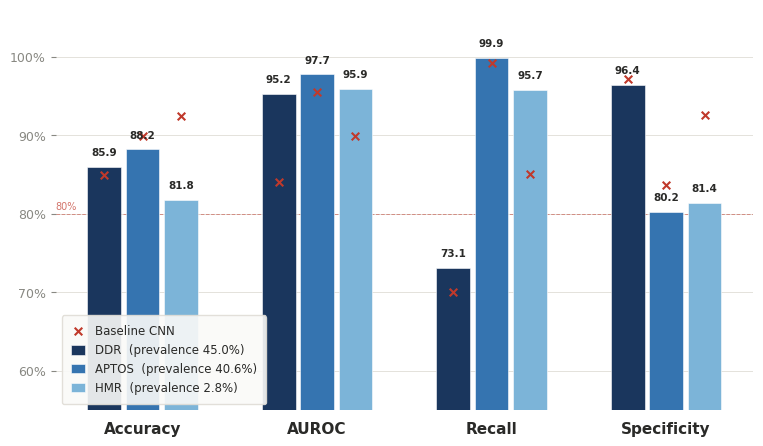

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def cnn_metric(ypred, gt):
    acc = accuracy_score(gt, np.round(ypred) > 0)
    recall = recall_score(gt, np.round(ypred) > 0)
    specificity = specificity_score(gt, np.round(ypred) > 0)
    auroc = roc_auc_score(gt, ypred / 5)
    return {
        "Accuracy": acc,
        "Recall": recall,
        "Specificity": specificity,
        "AUROC": auroc,
    }


cnn_ddr_pred = pd.read_pickle("CNN_results/DDR_test.pkl")
cnn_ddr_pred["image_id"] = cnn_ddr_pred["image_id"].apply(lambda x: x.stem)
cnn_ddr_pred["prediction"] = (cnn_ddr_pred["prediction"]).astype(int)
cnn_ddr_pred.set_index("image_id", inplace=True)
cnn_ddr = cnn_ddr_pred.merge(ddr_test_gt, left_on="image_id", right_on="image_id")
cnn_ddr_metrics = cnn_metric(cnn_ddr["prediction"], cnn_ddr["label"] > 1)

cnn_aptos_pred = pd.read_pickle("CNN_results/APTOS.pkl")
cnn_aptos_pred["image_id"] = cnn_aptos_pred["image_id"].apply(lambda x: x.stem)
cnn_aptos_pred["prediction"] = (cnn_aptos_pred["prediction"]).astype(int)
cnn_aptos_pred.set_index("image_id", inplace=True)
cnn_aptos = cnn_aptos_pred.merge(aptos_gt, left_on="image_id", right_on="image_id")
cnn_aptos_metrics = cnn_metric(cnn_aptos["prediction"], cnn_aptos["label"] > 1)

cnn_hmr_pred = pd.read_pickle("CNN_results/HMR.pkl")
cnn_hmr_pred["prediction"] = (cnn_hmr_pred["prediction"]).astype(int)
cnn_hmr_pred.set_index("image_id", inplace=True)
cnn_hmr = cnn_hmr_pred.merge(hmr_gt, left_on="image_id", right_on="image_id")
cnn_hmr_metrics = cnn_metric(cnn_hmr["prediction"], cnn_hmr["label"])

cnn_all_metrics = {
    "DDR": cnn_ddr_metrics,
    "APTOS": cnn_aptos_metrics,
    "HMR": cnn_hmr_metrics,
}
metrics = ["Accuracy", "AUROC", "Recall", "Specificity"]

metric_names = metrics
n_metrics = len(metric_names)
prevalences = metrics_df.loc["Proportion of Positives"].to_dict()
n_datasets = len(metrics_df.columns)

# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------
palette = {
    "DDR": "#1a365d",
    "APTOS": "#3574b0",
    "HMR": "#7cb4d8",
}
bg_color = "#fafaf800"
grid_color = "#e0ddd6"
text_color = "#2a2a28"
subtle_color = "#888882"

plt.rcParams.update(
    {
        "axes.unicode_minus": False,
    }
)

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bar_width = 0.22
x = np.arange(n_metrics)

for i, ds in enumerate(metrics_df.columns):
    print(f"Processing {ds}...")
    values = [metrics_df.loc[m, ds] for m in metric_names]
    offset = (i - (n_datasets - 1) / 2) * bar_width
    bars = ax.bar(
        x + offset,
        values,
        width=bar_width * 0.88,
        color=palette[ds],
        label=f"{ds}  (prevalence {prevalences[ds]:.1%})",
        edgecolor="white",
        linewidth=0.4,
        zorder=3,
    )
    cnn_score = [cnn_all_metrics[ds].get(m, None) for m in metric_names]

    ax.scatter(
        x + offset,
        cnn_score,
        color="#c0392b",
        s=30,
        marker="x",
        zorder=4,
        label="Baseline CNN" if i == 0 else None,
    )

    # Value labels
    for bar, v in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{v * 100:.1f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            fontweight=600,
            zorder=5,
            color=text_color,
        )


# ---------------------------------------------------------------------------
# Reference lines
# ---------------------------------------------------------------------------
ax.axhline(y=0.80, color="#c0392b", linewidth=0.7, linestyle="--", alpha=0.5, zorder=2)
ax.text(
    -0.5,
    0.803,
    "80%",
    fontsize=7,
    color="#c0392b",
    alpha=0.7,
    ha="left",
    va="bottom",
)

# ---------------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11, fontweight=600, color=text_color)
ax.set_ylim(0.55, 1.06)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.10))
ax.tick_params(axis="y", labelsize=9, colors=subtle_color)
ax.tick_params(axis="x", length=0, pad=8)

# Grid
ax.yaxis.grid(True, color=grid_color, linewidth=0.6, zorder=0)
ax.xaxis.grid(False)

# Spines
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------------------------------------------------------------
# Title & legend
# ---------------------------------------------------------------------------

legend = ax.legend(
    loc="lower left",
    fontsize=8.5,
    frameon=True,
    framealpha=0.9,
    edgecolor=grid_color,
    facecolor=bg_color,
    borderpad=0.8,
    handlelength=1.2,
    handleheight=0.9,
    labelspacing=0.5,
)
for text in legend.get_texts():
    text.set_color(text_color)


plt.savefig(
    "/home/clement/Documents/Projets/MultiStyleSeg/figures/DR_screening_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

DDR
Accuracy = 79.835063%
Recall = 56.272189%
Specificity = 99.081682%
aptos
Accuracy = 90.603660%
Recall = 96.904441%
Specificity = 86.298851%
HMR
Accuracy = 96.410256%
Recall = 69.148936%
Specificity = 97.205837%


In [12]:
hmr_gt["label"].max()

1